In [1]:
%pip install pandas


Note: you may need to restart the kernel to use updated packages.


Practical simple linear regrression

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('height-weight.csv',sep=",")

In [6]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0.5, 0, 'Weight')

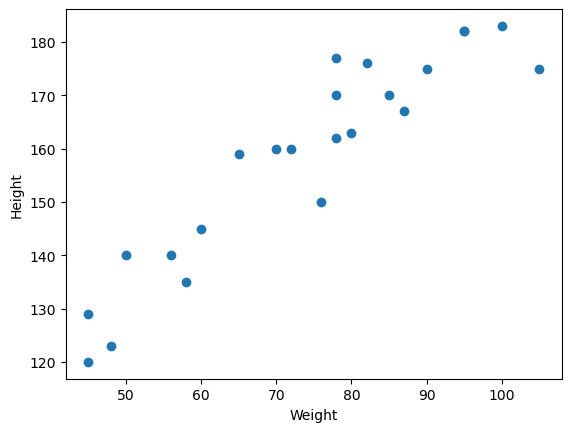

In [10]:
## scatter plot
plt.scatter(df['Weight'], df['Height'])
plt.ylabel('Height')
plt.xlabel('Weight')

In [12]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


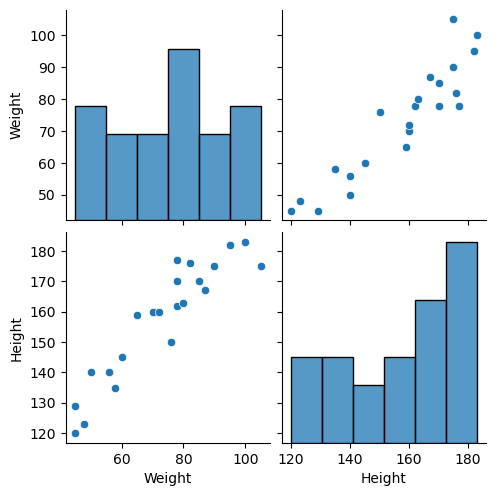

In [13]:
## seaborn for visualization
import seaborn as sns
sns.pairplot(df)

In [14]:
## independent and Dependent features 
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [ ]:
x=df[['Weight']] ## independent feature should be dataframe or 2D array
y = df['Height'] ## this variable can be 1D or series


In [26]:
x_series=df[['Weight']] ## independent feature should be dataframe or 2D array


In [33]:
## train test split
from sklearn.model_selection import train_test_split


In [35]:
X_train, X_test, Y_train, Y_test = train_test_split(x,y, test_size=0.25, random_state=42)

In [87]:
X_train

array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [88]:
x_test

array([[ 78.],
       [ 78.],
       [ 45.],
       [ 95.],
       [ 65.],
       [105.]])

In [ ]:
## standardization if dependent and independent feature have different units then 
# then after standaridization all data point will be converted to U(mean) =0 and standard deviation = 1 

In [40]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
# X_train
# scaler.fit()

array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [91]:
X_test=scaler.transform(X_test)

In [48]:
## apply simple linear regression
from sklearn.linear_model import LinearRegression

In [53]:
regression=LinearRegression(n_jobs=-1)

In [54]:
regression.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [56]:
regression.intercept_

np.float64(156.47058823529412)

In [77]:
print(f"slope  {regression.coef_}")
print(f"intercept  {regression.intercept_}")

slope  [17.2982057]
intercept  156.47058823529412


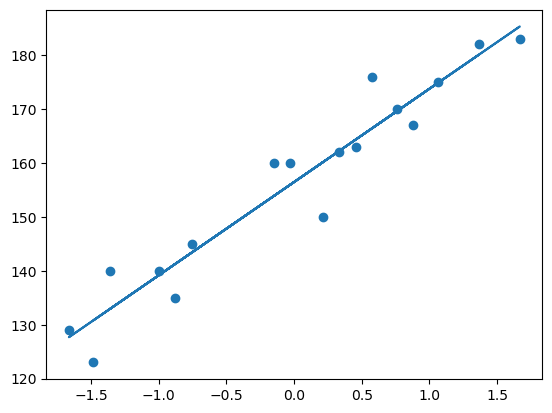

In [78]:
# plot the training data plot best fit line 
plt.scatter(X_train, Y_train)
plt.plot(X_train, regression.predict(X_train))

In [92]:
## Prediction of test data
# y_pred_test = 156.470 + 17.29(x_test)
print(X_test)

[[ 78.]
 [ 78.]
 [ 45.]
 [ 95.]
 [ 65.]
 [105.]]


In [80]:
y_pred= regression.predict(X_test)

In [66]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [82]:
mse= mean_squared_error(Y_test, y_pred)
mae= mean_absolute_error(Y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")    
print(f"Root Mean Squared Error: {rmse}")    

Mean Squared Error: 1886933.5397307763
Mean Absolute Error: 1336.1312312741586
Root Mean Squared Error: 1373.6569949338796
